# Practical 2: GNNs Applications to 3D Molecular data (Invariant and Equivariant GNNs)

Based on a notebook from Chaitanya K. Joshi, Charlie Harris, Ramon Viñas Torné

## Overview

Graph Neural Networks (GNNs) are a part of a broad and emerging research paradigm called **Geometric Deep Learning** -- devising neural network architectures that respect the invariances and symmetries in data. In this practical we will explore concepts seen in the lecture, paired with some new concepts with the aim of gently introducing the so called world of Geometric Deep Learning.

## Learning Objectives

The **aims** of this practical are as follows:

* Develop more familiarity with [**PyTorch Geometric**](https://pytorch-geometric.readthedocs.io/en/latest/) (PyG), a popular libary
for developing state-of-the-art GNNs and Geometric Deep Learning models. In particular, gaining familiarity with the `MessagePassing` base class for designing novel GNN layers and the `Data` object for representing graph datasets.
* Exploring some architectures for GNNs which we have seen in class and that go beyond the standard Message Passing Neural Networks.
* Gaining an appreciation of the fundamental principles behind constructing GNN layers that take advantage of **geometric information** for graph data located in **3D space**, a highly active area of GNN research.

### Structure and Grading

| Part | Topic | Points |
|------|-------|--------|
| **Part 0** | Installing dependencies, analyzing the data and problem setting | -- |
| **Part 1** | Building and training a GIN with PyG | 30 |
| **Part 2** | Message Passing with 3D Coordinates | 25 |
| **Part 3** | Invariance to 3D Symmetries | 15 |
| **Part 4** | Message Passing with Invariance to 3D Rotations and Translations | 30 |
| | **Total** | **100** |

### What to do

You only need to add code when you see a `#TODO` in the code cell. Whenever there is a question to answer, it will be in a red box (see example below). Beneath you'll find an empty markdown cell in which you can provide your answer.


# Part 0.1: Installing Dependencies and Helpers

In [1]:
import subprocess
subprocess.run(["pip", "install", "numpy<2"], check=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 109.6 MB/s  0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.3.5
    Uninstalling numpy-2.3.5:
      Successfully uninstalled numpy-2.3.5


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jax 0.9.0.1 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.9.0.1 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
pytesmo 0.18.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
obspy 1.4.2 requires sqlalchemy<2, but you have sqlalchemy 2.0.43 which is incompatible.
pygimli 1.5.4 requires numpy>=2.1, but you have numpy 1.26.4 which is incompatible.
tetgen 0.6.7 requires numpy<3,>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
pgcore 1.5.4 requires numpy>=2.1, but you have numpy 1.26.4 which is incompatible.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.


CompletedProcess(args=['pip', 'install', 'numpy<2'], returncode=0)

In [2]:
!pip install torch==2.0.0+cu118 torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install networkx

!pip install torch_scatter torch_sparse torch_cluster torch_spline_conv -f https://data.pyg.org/whl/torch-2.0.0+cu118.html
!pip install torch-geometric==2.3.0

!pip install -q rdkit-pypi
!pip install -q py3Dmol

Looking in indexes: https://download.pytorch.org/whl/cu118
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 GB 67.3 MB/s  0:00:136m0:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.3/63.3 MB 162.5 MB/s  0:00:00eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 126.3 MB/s  0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of torchvision to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 112.0 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 117.4 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 103.9 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 111.0 MB/s  0:00:00
INFO: pip is still looking at multiple versions of torchvision to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━

In [4]:
import torch
import torch_geometric


print("PyTorch version {}".format(torch.__version__))
print("PyG version {}".format(torch_geometric.__version__))

PyTorch version 2.0.0+cu118
PyG version 2.3.0


In [5]:
# Set random seed for deterministic results

import random
import numpy as np

def seed(seed=0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed(0)

The following helpers are used for the visualization of the molecules and for representing some geometric properties. 
You don't need to understand the code, it's sufficient to just use them.

In [6]:
# Helper functions for data preparation. 

from torch_geometric.utils import remove_self_loops


class SetTarget(object):
    """
    This transform mofifies the labels vector per data sample to only keep
    the label for a specific target (there are 19 targets in QM9).

    Note: for this practical, we have hardcoded the target to be target #0,
    i.e. the electric dipole moment of a drug-like molecule.
    (https://en.wikipedia.org/wiki/Electric_dipole_moment)
    """
    def __call__(self, data):
        target = 0 # we hardcoded choice of target
        data.y = data.y[:, target]
        return data


class CompleteGraph(object):
    """
    This transform adds all pairwise edges into the edge index per data sample,
    then removes self loops, i.e. it builds a fully connected or complete graph
    """
    def __call__(self, data):
        device = data.edge_index.device

        row = torch.arange(data.num_nodes, dtype=torch.long, device=device)
        col = torch.arange(data.num_nodes, dtype=torch.long, device=device)

        row = row.view(-1, 1).repeat(1, data.num_nodes).view(-1)
        col = col.repeat(data.num_nodes)
        edge_index = torch.stack([row, col], dim=0)

        edge_attr = None
        if data.edge_attr is not None:
            idx = data.edge_index[0] * data.num_nodes + data.edge_index[1]
            size = list(data.edge_attr.size())
            size[0] = data.num_nodes * data.num_nodes
            edge_attr = data.edge_attr.new_zeros(size)
            edge_attr[idx] = data.edge_attr

        edge_index, edge_attr = remove_self_loops(edge_index, edge_attr)
        data.edge_attr = edge_attr
        data.edge_index = edge_index

        return data

In [7]:
# Helper functions for visualization

import rdkit.Chem as Chem

allowable_atoms = [
    "H",
    "C",
    "N",
    "O",
    "F",
    "C",
    "Cl",
    "Br",
    "I",
    "H",
    "Unknown",
]

def to_atom(t):
    try:
        return allowable_atoms[int(t.argmax())]
    except:
        return "C"


def to_bond_index(t):
    t_s = t.squeeze()
    return [1, 2, 3, 4][
        int(
            torch.dot(
                t_s,
                torch.tensor(
                    range(t_s.size()[0]), dtype=torch.float, device=t.device
                ),
            ).item()
        )
    ]

def to_rdkit(data, device=None):
    has_pos = False
    node_list = []
    for i in range(data.x.size()[0]):
        node_list.append(to_atom(data.x[i][:5]))

    # create empty editable mol object
    mol = Chem.RWMol()
    # add atoms to mol and keep track of index
    node_to_idx = {}
    invalid_idx = set([])
    for i in range(len(node_list)):
        if node_list[i] == "Stop" or node_list[i] == "H":
            invalid_idx.add(i)
            continue
        a = Chem.Atom(node_list[i])
        molIdx = mol.AddAtom(a)
        node_to_idx[i] = molIdx

    added_bonds = set([])
    for i in range(0, data.edge_index.size()[1]):
        ix = data.edge_index[0][i].item()
        iy = data.edge_index[1][i].item()
        bond = to_bond_index(data.edge_attr[i]) 
        # bond = 1
        # add bonds between adjacent atoms

        if data.edge_attr[i].sum() == 0:
          continue

        if (
            (str((ix, iy)) in added_bonds)
            or (str((iy, ix)) in added_bonds)
            or (iy in invalid_idx or ix in invalid_idx)
        ):
            continue
        # add relevant bond type (there are many more of these)

        if bond == 0:
            continue
        elif bond == 1:
            bond_type = Chem.rdchem.BondType.SINGLE
            mol.AddBond(node_to_idx[ix], node_to_idx[iy], bond_type)
        elif bond == 2:
            bond_type = Chem.rdchem.BondType.DOUBLE
            mol.AddBond(node_to_idx[ix], node_to_idx[iy], bond_type)
        elif bond == 3:
            bond_type = Chem.rdchem.BondType.TRIPLE
            mol.AddBond(node_to_idx[ix], node_to_idx[iy], bond_type)
        elif bond == 4:
            bond_type = Chem.rdchem.BondType.SINGLE
            mol.AddBond(node_to_idx[ix], node_to_idx[iy], bond_type)

        added_bonds.add(str((ix, iy)))

    if has_pos:
        conf = Chem.Conformer(mol.GetNumAtoms())
        for i in range(data.pos.size(0)):
            if i in invalid_idx:
                continue
            p = Point3D(
                data.pos[i][0].item(),
                data.pos[i][1].item(),
                data.pos[i][2].item(),
            )
            conf.SetAtomPosition(node_to_idx[i], p)
        conf.SetId(0)
        mol.AddConformer(conf)

    # Convert RWMol to Mol object
    mol = mol.GetMol()
    mol_frags = Chem.rdmolops.GetMolFrags(mol, asMols=True, sanitizeFrags=False)
    largest_mol = max(mol_frags, default=mol, key=lambda m: m.GetNumAtoms())
    return largest_mol


def MolTo3DView(mol, size=(300, 300), style="stick", surface=False, opacity=0.5):
    """Draw molecule in 3D

    Args:
    ----
        mol: rdMol, molecule to show
        size: tuple(int, int), canvas size
        style: str, type of drawing molecule
               style can be 'line', 'stick', 'sphere', 'carton'
        surface, bool, display SAS
        opacity, float, opacity of surface, range 0.0-1.0
    Return:
    ----
        viewer: py3Dmol.view, a class for constructing embedded 3Dmol.js views in ipython notebooks.
    """
    assert style in ('line', 'stick', 'sphere', 'carton')

    mol = Chem.AddHs(mol)
    AllChem.EmbedMolecule(mol)
    AllChem.MMFFOptimizeMolecule(mol, maxIters=200)
    mblock = Chem.MolToMolBlock(mol)
    viewer = py3Dmol.view(width=size[0], height=size[1])
    viewer.addModel(mblock, 'mol')
    viewer.setStyle({style:{}})
    if surface:
        viewer.addSurface(py3Dmol.SAS, {'opacity': opacity})
    viewer.zoomTo()
    return viewer

def smi2conf(smiles):
    '''Convert SMILES to rdkit.Mol with 3D coordinates'''
    mol = Chem.MolFromSmiles(smiles)
    if mol is not None:
        mol = Chem.AddHs(mol)
        AllChem.EmbedMolecule(mol)
        AllChem.MMFFOptimizeMolecule(mol, maxIters=200)
        return mol
    else:
        return None

In [8]:
# For storing experimental results over the course of the practical

import pandas as pd

all_final_results = {}
all_training_results = {}

Great! We are ready to dive into the 2nd Practical!

# Part 0.2: Introduction to Molecular Property Prediction with PyTorch Geometric

In this section we will see how Graph Neural Networks (GNNs) can be employed for predicting chemical properties of molecules, an impactful real-world application of Geometric Deep Learning. For this notebooks we will mostly use PyTorch Geometric, which we introduced in the previous Practical (with Part 3)

## Molecular Property Prediction

Molecules are a great example of an object from nature that can easily be represented as a graph of atoms (nodes) connected by bonds (edges).
A popular application of GNNs in chemistry is the task of **Molecular Property Prediction**. The goal is to train a GNN model from historical experimental data that can predict useful properties of drug-like molecules. The model's predictions can then be used to guide the drug design process.

<img src="https://github.com/chaitjo/dump/raw/main/molproppred.png">

One famous example of GNNs being used in molecular property prediction is in the world of **antibiotic discovery**, an area with a potentially massive impact on humanity and infamously little innovation. 

## The QM9 Dataset

QM9 (Quantum Mechanics dataset 9) is a dataset consisting of about **130,000 small molecules** with 19 regression targets. Since being used by [MoleculeNet](https://arxiv.org/abs/1703.00564), it has become a popular dataset to benchmark new architectures for molecular property prediction.

Specifically, we will be predicting the [electric dipole moment](https://en.wikipedia.org/wiki/Electric_dipole_moment) of drug-like molecules. According to Wikipedia:
> "The electric dipole moment is a measure of the separation of positive and negative electrical charges within a system, that is, a measure of the system's overall polarity."

We can visualize this concept via the water molecule H<sub>2</sub>0, which forms a dipole due to its slightly different distribution of negative (blue) and postive (red) charge.

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/1/15/Water-elpot-transparent-3D-balls.png/500px-Water-elpot-transparent-3D-balls.png" width="25%">

You do not need to worry about the exact physical and chemical principles that underpin dipole moments. As you might imagine, writing the equations from first principles to predict a property like this, espeically for complex molecules (e.g. proteins), is very difficult. All you need know (for the sake of this practical anyway) is that these molecules can be representated as graphs with node and edge features as well as **spatial information** that we can use to train a GNN model using the ground truth labels.

Now let us load the QM9 dataset and explore how molecular graphs are represented. PyG makes this extremely convenient.

(The dataset may take a few minutes to download.)

In [9]:
import os
import pickle
import warnings
import zipfile
from tqdm import tqdm
from torch_geometric.data import Data
from torch_geometric.datasets import QM9
from torch_geometric.data.download import download_url


class QM9DownloadWrapper(QM9):
    @property
    def raw_file_names(self):
        return ['qm9_v3.pt']

    def download(self):
        zip_path = download_url(self.processed_url, self.raw_dir)
        with zipfile.ZipFile(zip_path, 'r') as z:
            z.extractall(self.raw_dir)
        os.unlink(zip_path)

    def process(self):
        data_list = self._safe_torch_load(self.raw_paths[0])
        data_list = [Data(**data_dict) for data_dict in data_list]

        if self.pre_filter is not None:
            data_list = [d for d in data_list if self.pre_filter(d)]

        if self.pre_transform is not None:
            data_list = [
                self.pre_transform(d)
                for d in tqdm(data_list, desc="Applying pre_transform")
            ]

        data, slices = self.collate(data_list)
        torch.save((data, slices), self.processed_paths[0])

    def _safe_torch_load(self, path, map_location=None):
        try:
            return torch.load(path, map_location=map_location, weights_only=True)
        except pickle.UnpicklingError:
            warnings.warn("Loading with weights_only=False.")
            return torch.load(path, map_location=map_location, weights_only=False)

In [10]:
import torch_geometric.transforms as T

path = './qm9'

# Transforms which are applied during data loading:
# (1) Fully connect the graphs, (2) Set the target to be 0
transform = T.Compose([CompleteGraph(), SetTarget()])

# Load the QM9 dataset with the transforms defined
dataset = QM9DownloadWrapper(path, pre_transform=transform)

# Normalize targets per data sample to mean = 0 and std = 1.
mean = dataset.data.y.mean(dim=0, keepdim=True)
std = dataset.data.y.std(dim=0, keepdim=True)
dataset.data.y = (dataset.data.y - mean) / std
mean, std = mean.item(), std.item()
print(mean, std)

Processing...
/opt/micromamba/lib/python3.11/site-packages/torch/_utils.py:776: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()
Applying pre_transform: 100%|██████████| 130831/130831 [00:26<00:00, 5007.30it/s]
Done!


2.672952890396118 1.5034793615341187


/opt/micromamba/lib/python3.11/site-packages/torch_geometric/data/in_memory_dataset.py:157: UserWarning: It is not recommended to directly access the internal storage format `data` of an 'InMemoryDataset'. If you are absolutely certain what you are doing, access the internal storage via `InMemoryDataset._data` instead to suppress this warning. Alternatively, you can access stacked individual attributes of every graph via `dataset.{attr_name}`.
  warnings.warn(msg)


## Data Preparation and Splitting

The QM9 dataset has over **130,000** molecular graphs!

Let us create a more tractable sub-set of **3,000** molecular graphs for the purposes of this practical and separate it into training, validation, and test sets. We shall use 1,000 graphs each for training, validation, and testing.

Towards the end of this practical, you will get to experiment with the full/larger sub-sets of the QM9 dataset, too.

In [11]:
from torch_geometric.loader import DataLoader

print(f"Total number of samples: {len(dataset)}.")

# Split datasets (in case of using the full dataset)
# test_dataset = dataset[:10000]
# val_dataset = dataset[10000:20000]
# train_dataset = dataset[20000:]

# Split datasets (our 3K subset)
train_dataset = dataset[:1000]
val_dataset = dataset[1000:2000]
test_dataset = dataset[2000:3000]
print(f"Created dataset splits with {len(train_dataset)} training, {len(val_dataset)} validation, {len(test_dataset)} test samples.")

# Create dataloaders with batch size = 32
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

Total number of samples: 130831.
Created dataset splits with 1000 training, 1000 validation, 1000 test samples.


### Understanding the Dataset
**Atom features (`data.x`)** - $\mathbb{R}^{|V| \times 11}$
- 1st-5th features: Atom type (one-hot: H, C, N, O, F)
- 6th feature (also `data.z`): Atomic number (number of protons).
- 7th feature: Aromatic (binary)
- 8th-10th features: Electron orbital hybridization (one-hot: sp, sp2, sp3)
- 11th feature: Number of hydrogens

**Edge Index (`data.edge_index`)** - $\mathbb{R}^{2×|E|}$
- A tensor of dimensions 2 x `num_edges` that describe the edge connectivity of the graph

**Edge features (`data.edge_attr`)** - $\mathbb{R}^{|E|\times 4}$
- 1st-4th features: bond type (one-hot: single, double, triple, aromatic)

**Atom positions (`data.pos`)** - $\mathbb{R}^{|V|\times 3}$
- 3D coordinates of each atom . (We will talk about their importance later in the practical.)

**Target (`data.y`)** - $\mathbb{R}^{1}$
- A scalar value corresponding to the molecules electric dipole moment

**❗️Note:** We will be using **fully-connected graphs** (i.e. all atoms in a molecule are connected to each other, except self-loops). The information about the molecule structures will be available to the models through the edge features (`data.edge_attr`) as follows:
- When two atoms are physically connected, the edge attributes indicate the **bond type** (single, double, triple, or aromatic) through a one-hot vector.
- When two atoms are not physically connected, **all edge attributes** are **zero**.
We will later study the advantages/downsides of fully-connected adjacency matrices versus sparse adjacency matrices (where an edge between two atoms is present only when there exists a physical connection between them).


## Visualising Molecular Graphs

To get a better understanding of how the QM9 molecular graphs look like, let's visualise a few samples from the training set along with their corresponding target (their dipole moment).

In the following plot we visualise **sparse graphs** where edges represent physical connections (i.e. bonds). 

**Note:** we are using some pre-implemented code to convert the PyG graph into a Molecule object that can be used by RDKit, a python package for chemistry and visualing molecules. It is not important for you to understand RDKit beyond visualisation purposes.

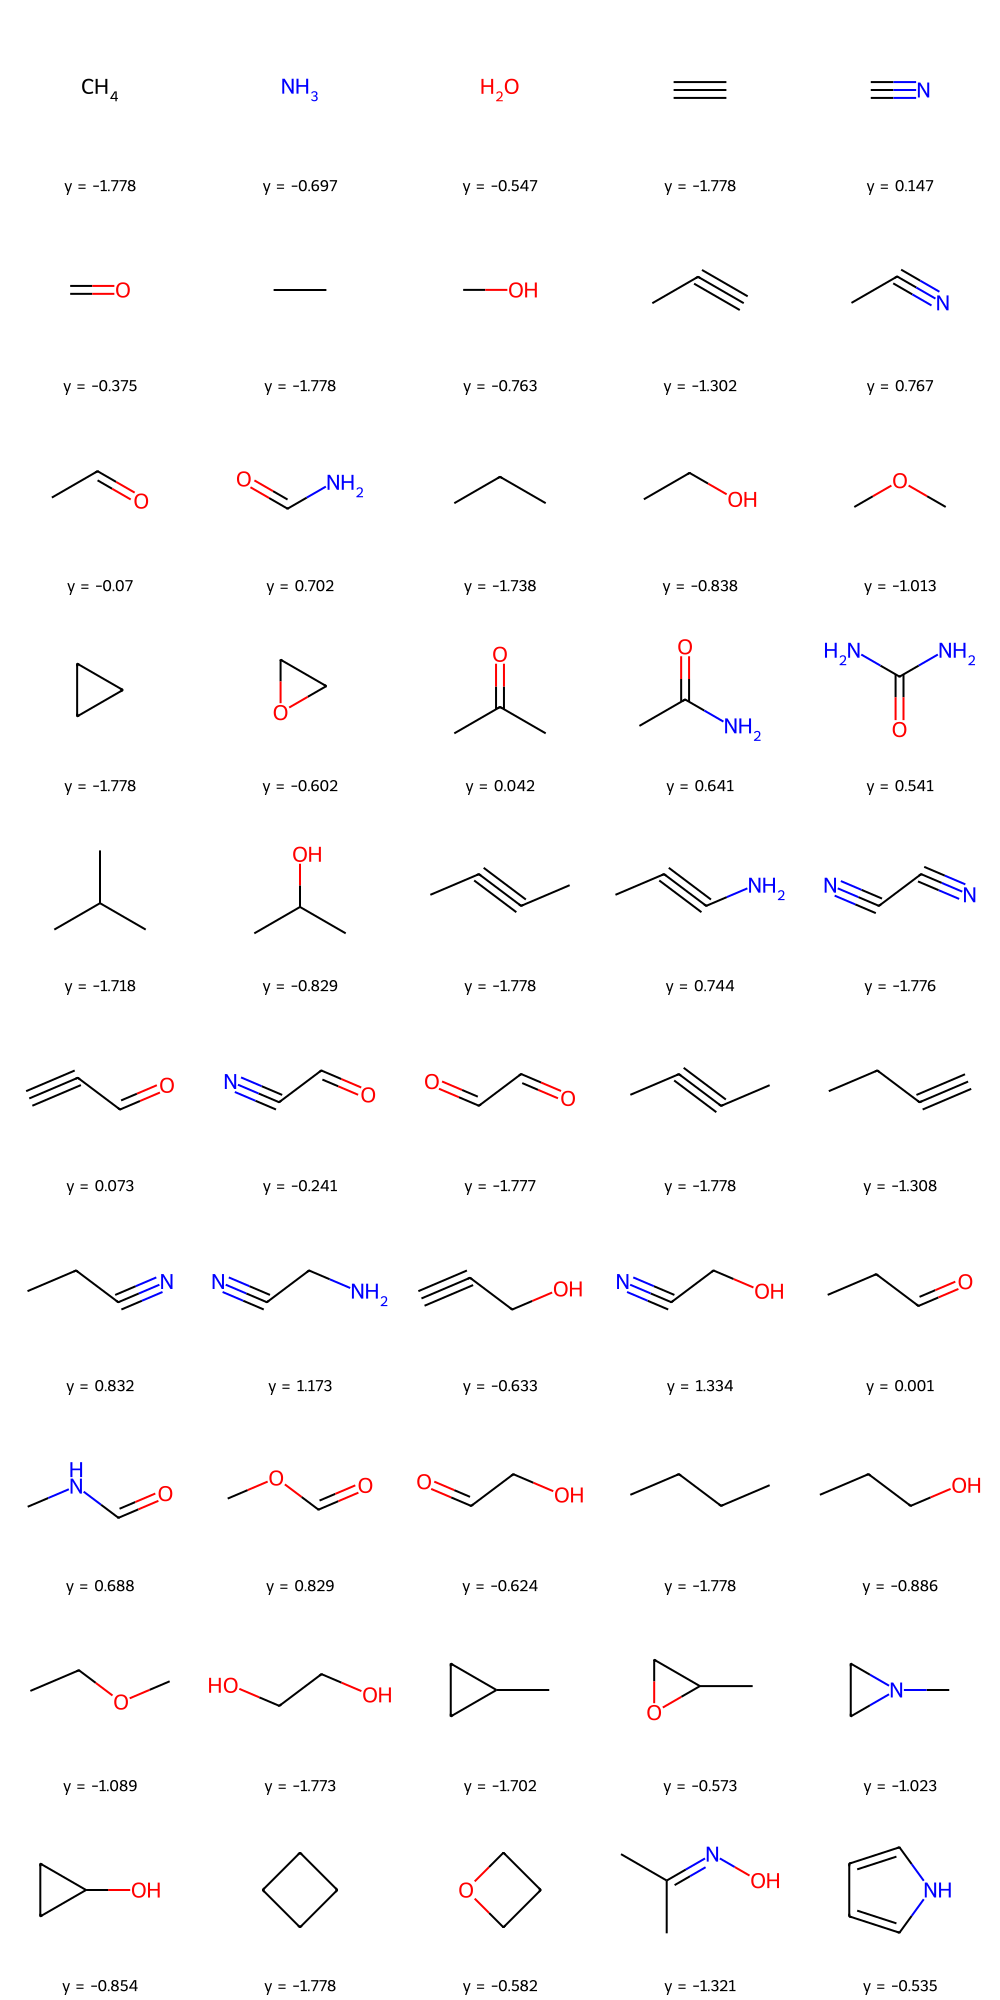

In [12]:
num_viz = 50
mols = [to_rdkit(train_dataset[i]) for i in range(num_viz)]
values = [str(round(float(train_dataset[i].y), 3)) for i in range(num_viz)]

Chem.Draw.MolsToGridImage(mols, legends=[f"y = {value}" for value in values], molsPerRow=5)

Let us print all the attributes (along with their shapes) that a single PyG molecular graph in our dataset contains:

In [13]:
data = train_dataset[0] # one data sample, i.e. molecular graph
print(data)

Data(x=[5, 11], edge_index=[2, 20], edge_attr=[20, 4], y=[1], pos=[5, 3], idx=[1], name='gdb_1', z=[5])


In [14]:
print(f"\nThis molecule has {data.x.shape[0]} atoms, and {data.edge_attr.shape[0]} edges.")

print(f"\nFor each atom, we are given a feature vector with {data.x.shape[1]} entries (described above).")

print(f"\nFor each edge, we are given a feature vector with {data.edge_attr.shape[1]} entries (also described above).")

print(f"\nIn the next section, we will learn how to build a GNN in the Message Passing flavor to process the node and edge features of molecular graphs and predict their properties.")

print(f"\nEach atom also has a {data.pos.shape[1]}-dimensional coordinate associated with it. We will talk about their importance later in the practical.")

print(f"\nFinally, we have {data.y.shape[0]} regression target for the entire molecule.")


This molecule has 5 atoms, and 20 edges.

For each atom, we are given a feature vector with 11 entries (described above).

For each edge, we are given a feature vector with 4 entries (also described above).

In the next section, we will learn how to build a GNN in the Message Passing flavor to process the node and edge features of molecular graphs and predict their properties.

Each atom also has a 3-dimensional coordinate associated with it. We will talk about their importance later in the practical.

Finally, we have 1 regression target for the entire molecule.


# Part 0.3: Problem Setting and MPNN Baseline

Firstly, let us formalise our molecular property prediction pipeline. We follow the notations used in the lecture (see Lecture 3 and 4)

### Graph
Consider a molecular graph $G = \left( V, E \right)$, where $V$ is a set of $n$ nodes, and $E$ is a set of edges associated with the nodes. For each node $u \in V$, we are given a $d_n$-dimensional initial feature vector $x_u \in \mathbb{R}^{d_n}$.
For each edge $(u, v) \in E$, we are given a $d_e$-dimensional initial feature vector $e_{uv} \in \mathbb{R}^{d_e}$. For QM9 graphs, $d_n = 11, d_e = 4$.

### Label
Associated with each graph $G$ is a scalar target or label $y \in \mathbb{R}$, which we would like to predict.

We will design a Message Passing Neural Network for graph property prediction to do this. Our MPNN will consist of several layers of message passing, followed by a global pooling and prediction head.

### MPNN Layer
The Message Passing operation iteratively updates node features from layer $t-1$ to layer $t$ for every node $u \in V$ via the following set of equations:

$$
h_u^{0} = x_u \qquad \text{initialize}
$$

$$
m_{uv}^{t} = \psi(h_u^{t-1}, h_v^{t-1}, e_{uv}) \qquad \text{message}
$$

$$
m_u^{t} = \bigoplus_{v \in \mathcal{N}(u)} m_{uv}^{t} \qquad \text{aggregate}
$$

$$
h_u^{t} = \phi(h_u^{t-1}, m_u^{t}) \qquad \text{update/combine}
$$


### Global Pooling and Prediction Head
After $L$ layers of message passing, we obtain the final node features $h_u^{\ell=L}$. As we have a single target $y$ per graph, we must pool all node features into a single graph feature or graph embedding $h_G \in \mathbb{R}^d$ via another permutation-invariant function $R$, sometimes called the 'readout' function, as follows:
$$
h_G = R ( (h_u^{\ell=L})_{u \in \mathcal{V}} ).
$$
We will use global average pooling over all node features, i.e.
$$
h_G = \frac{1}{|\mathcal{V}|} \sum_{u \in \mathcal{V}} h_u^{\ell=L}.
$$

The graph embedding $h_G$ is passed through a linear prediction head $W_{pred} \in \mathbb{R}^{d} \rightarrow \mathbb{R}^1$ to obtain the overall prediction $\hat y \in \mathbb{R}^1$:
$$
\hat y = W_{pred} \left( h_G \right).
$$

### Loss Function
Our MPNN graph property prediction model can be trained end-to-end via minimizing the standard mean-squared error loss for regression:
$$
\mathcal{L}_{MSE} = \lVert y - \hat y \rVert^2_2.
$$

## Coding the basic Message Passing Neural Network Layer

We are now ready to define a basic MPNN layer which implements what we have described above. In particular, we will code up the **MPNN Layer** first. (We will code up the other parts subsequently.)

To do so, we will inherit from the `MessagePassing` base class, which automatically takes care of message propagation and is extremely useful to develop advanced GNN models. To implement a custom MPNN, the user only needs to define the behaviour of the `message` (i.e. $\psi$), the `aggregate`(i.e. $\oplus$), and `update` (i.e. $\phi$) functions. You may also refer to the [PyG documentation](https://pytorch-geometric.readthedocs.io/en/latest/notes/create_gnn.html) for implementing custom message passing layers.

Below, we provide the implementation of a standard MPNN layer as an example, with extensive inline comments to help you figure out what is going on. We will also use it later on for some tasks.

**❗️Note:** In the lectures, we always  *u* and *v* to denote nodes of a graph. However, PyG's MessagePassing uses the _i and _j suffixes (not _u and _v) to automatically split variables passed to propagate() into destination and source node. Therefore in the code we will use i and j, instead.

In [15]:
from torch_geometric.nn import MessagePassing, global_mean_pool
import torch.nn as nn 
from torch_scatter import scatter


class MPNNLayer(MessagePassing):
    def __init__(self, emb_dim=64, edge_dim=4, aggr='add'):
        """Message Passing Neural Network Layer

        Args:
            emb_dim: (int) - hidden dimension `d`
            edge_dim: (int) - edge feature dimension `d_e`
            aggr: (str) - aggregation function (sum/mean/max)
        """
        # Set the aggregation function
        super().__init__(aggr=aggr)

        self.emb_dim = emb_dim
        self.edge_dim = edge_dim

        # MLP `\psi` for computing messages `m_ij`
        # Implemented as a stack of Linear->BN->ReLU->Linear->BN->ReLU
        # dims: (2d + d_e) -> d
        self.mlp_msg = nn.Sequential(
            nn.Linear(2*emb_dim + edge_dim, emb_dim), nn.BatchNorm1d(emb_dim), nn.ReLU(),
            nn.Linear(emb_dim, emb_dim), nn.BatchNorm1d(emb_dim), nn.ReLU()
          )

        # MLP `\phi` for computing updated node features `h_i^{l+1}`
        # Implemented as a stack of Linear->BN->ReLU->Linear->BN->ReLU
        # dims: 2d -> d
        self.mlp_upd = nn.Sequential(
            nn.Linear(2*emb_dim, emb_dim), nn.BatchNorm1d(emb_dim), nn.ReLU(),
            nn.Linear(emb_dim, emb_dim), nn.BatchNorm1d(emb_dim), nn.ReLU()
          )

    def forward(self, h, edge_index, edge_attr):
        """
        The forward pass updates node features `h` via one round of message passing.

        As our MPNNLayer class inherits from the PyG MessagePassing parent class,
        we simply need to call the `propagate()` function which starts the
        message passing procedure: `message()` -> `aggregate()` -> `update()`.

        The MessagePassing class handles most of the logic for the implementation.
        To build custom GNNs, we only need to define our own `message()`,
        `aggregate()`, and `update()` functions (defined subsequently).

        Args:
            h: (n, d) - initial node features
            edge_index: (e, 2) - pairs of edges (u, v)
            edge_attr: (e, d_e) - edge features

        Returns:
            out: (n, d) - updated node features
        """
        out = self.propagate(edge_index, h=h, edge_attr=edge_attr)
        return out

    def message(self, h_i, h_j, edge_attr):
        """Step (1) Message

        The `message()` function constructs messages from source nodes v
        to destination nodes u for each edge (i, j) in `edge_index`.

        The arguments can be a bit tricky to understand: `message()` can take
        any arguments that were initially passed to `propagate`. Additionally,
        we can differentiate destination nodes and source nodes by appending
        `_i` or `_j` to the variable name, e.g. for the node features `h`, we
        can use `h_i` and `h_j`.

        This part is critical to understand as the `message()` function
        constructs messages for each edge in the graph. The indexing of the
        original node features `h` (or other node variables) is handled under
        the hood by PyG.

        Args:
            h_i: (e, d) - destination node features
            h_j: (e, d) - source node features
            edge_attr: (e, d_e) - edge features

        Returns:
            msg: (e, d) - messages `m_ij` passed through MLP `\psi`
        """
        msg = torch.cat([h_i, h_j, edge_attr], dim=-1)
        return self.mlp_msg(msg)

    def aggregate(self, inputs, index):
        """Step (2) Aggregate

        The `aggregate` function aggregates the messages from neighboring nodes,
        according to the chosen aggregation function ('sum' by default).

        Args:
            inputs: (e, d) - messages `m_ij` from source to destination nodes
            index: (e,) - list of destination nodes for each edge/message in `input`

        Returns:
            aggr_out: (n, d) - aggregated messages `m_i`
        """
        return scatter(inputs, index, dim=self.node_dim, reduce=self.aggr)

    def update(self, aggr_out, h):
        """
        Step (3) Update

        The `update()` function computes the final node features by combining the
        aggregated messages with the initial node features.

        `update()` takes the first argument `aggr_out`, the result of `aggregate()`,
        as well as any optional arguments that were initially passed to
        `propagate()`. E.g. in this case, we additionally pass `h`.

        Args:
            aggr_out: (n, d) - aggregated messages `m_i`
            h: (n, d) - initial node features

        Returns:
            upd_out: (n, d) - updated node features passed through MLP `\phi`
        """
        upd_out = torch.cat([h, aggr_out], dim=-1)
        return self.mlp_upd(upd_out)

    def __repr__(self) -> str:
        return (f'{self.__class__.__name__}(emb_dim={self.emb_dim}, aggr={self.aggr})')

Let's use this **Message Passing layer** to code up the full **MPNN graph property prediction model**. This model will take as input molecular graphs, process them via multiple MPNN layers, and predict a single property for each of them.

In [16]:
class MPNNModel(nn.Module):
    def __init__(self, num_layers=4, emb_dim=64, in_dim=11, edge_dim=4, out_dim=1):
        """Message Passing Neural Network model for graph property prediction

        Args:
            num_layers: (int) - number of message passing layers `L`
            emb_dim: (int) - hidden dimension `d`
            in_dim: (int) - initial node feature dimension `d_n`
            edge_dim: (int) - edge feature dimension `d_e`
            out_dim: (int) - output dimension (fixed to 1)
        """
        super().__init__()

        # Linear projection for initial node features
        # dim: d_n -> d
        self.lin_in = nn.Linear(in_dim, emb_dim)

        # Stack of MPNN layers
        self.convs = torch.nn.ModuleList()
        for layer in range(num_layers):
            self.convs.append(MPNNLayer(emb_dim, edge_dim, aggr='add'))

        # Global pooling/readout function `R` (mean pooling)
        # PyG handles the underlying logic via `global_mean_pool()`
        self.pool = global_mean_pool

        # Linear prediction head
        # dim: d -> out_dim
        self.lin_pred = nn.Linear(emb_dim, out_dim)

    def forward(self, data):
        """
        Args:
            data: (PyG.Data) - batch of PyG graphs

        Returns:
            out: (batch_size, out_dim) - prediction for each graph
        """
        h = self.lin_in(data.x) # (n, d_n) -> (n, d)

        for conv in self.convs:
            h = h + conv(h, data.edge_index, data.edge_attr) # (n, d) -> (n, d)
            # Note that we add a residual connection after each MPNN layer

        h_graph = self.pool(h, data.batch) # (n, d) -> (batch_size, d)

        out = self.lin_pred(h_graph) # (batch_size, d) -> (batch_size, 1)

        return out.view(-1)

Before we dive into training and evaluation this model, as we did in the previous practical let's define some sanity checks to test permutation invariance and equivaraince properties of the model and the layer. They will be useful later on.

In [17]:
from torch_geometric.utils import to_dense_adj, dense_to_sparse

def permute_graph(data, perm):
    """Helper function for permuting PyG Data object attributes consistently.
    """
    # Permute the node attribute ordering
    data.x = data.x[perm]
    data.pos = data.pos[perm]
    data.z = data.z[perm]
    data.batch = data.batch[perm]

    # Permute the edge index
    adj = to_dense_adj(data.edge_index)
    adj = adj[:, perm, :]
    adj = adj[:, :, perm]
    data.edge_index = dense_to_sparse(adj)[0]

    # Rebuild edge_attr to match the new edge_index shape
    num_edges = data.edge_index.shape[1]
    edge_dim = data.edge_attr.shape[1]
    data.edge_attr = torch.zeros(num_edges, edge_dim)

    return data

def permutation_invariance_unit_test(module, dataloader):
    """Unit test for checking whether a module (GNN model) is
    permutation invariant.
    """
    module.eval()
    it = iter(dataloader)
    data = next(it)

    # Set edge_attr to dummy values (forsimplicity)
    data.edge_attr = torch.zeros(data.edge_attr.shape)

    # Forward pass on original example
    out_1 = module(data)

    # Create random permutation
    perm = torch.randperm(data.x.shape[0])
    data = permute_graph(data, perm)

    # Forward pass on permuted example
    out_2 = module(data)

    # Check whether output varies after applying transformations
    return torch.allclose(out_1, out_2, atol=1e-03)


def permutation_equivariance_unit_test(module, dataloader):
    """Unit test for checking whether a module (GNN layer) is
    permutation equivariant.
    """
    module.eval()  # this line is important because BatchNorm behaves differently 
    # depending on whether the model is in training mode (default) or eval mode
    it = iter(dataloader)
    data = next(it)

    # Set edge_attr to dummy values (for simplicity)
    data.edge_attr = torch.zeros(data.edge_attr.shape)

    # Forward pass on original example
    out_1 = module(data.x, data.edge_index, data.edge_attr)

    # Create random permutation
    perm = torch.randperm(data.x.shape[0])
    data = permute_graph(data, perm)

    # Forward pass on permuted example
    out_2 = module(data.x, data.edge_index, data.edge_attr)

    # Check whether output varies after applying transformations
    return torch.allclose(out_1[perm], out_2, atol=1e-04)

Now that we have defined the unit tests for permutation invariance (for the full MPNN model) and permutation equivariance (for the MPNN layer), let us perform the sanity check:

In [18]:
# Instantiate temporary model, layer, and dataloader for unit testing
layer = MPNNLayer(emb_dim=11, edge_dim=4)
model = MPNNModel(num_layers=4, emb_dim=64, in_dim=11, edge_dim=4, out_dim=1)
dataloader = DataLoader(train_dataset, batch_size=1, shuffle=True)

# Permutation invariance unit test for MPNN model
print(f"Is {type(model).__name__} permutation invariant? --> {permutation_invariance_unit_test(model, dataloader)}!")

# Permutation equivariance unit for MPNN layer
print(f"Is {type(layer).__name__} permutation equivariant? --> {permutation_equivariance_unit_test(layer, dataloader)}!")

Is MPNNModel permutation invariant? --> True!
Is MPNNLayer permutation equivariant? --> True!


## Training and Evaluating Models

Now we can train and evaluate our model on QM9. We have provided a **basic experiment loop** which takes as input the model and dataloaders, performs training, and returns the final performance on the **validation** and **test set**.

We will be training a `MPNNModel` consisting of 4 layers of message passing with a hidden dimension of 64.

In [19]:
# Helper functions for managing experiments, training, and evaluating models.

import time
import torch.nn.functional as F

def train(model, train_loader, optimizer, device):
    model.train()
    loss_all = 0

    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        y_pred = model(data)
        loss = F.mse_loss(y_pred, data.y)
        loss.backward()
        loss_all += loss.item() * data.num_graphs
        optimizer.step()
    return loss_all / len(train_loader.dataset)


def eval(model, loader, device):
    model.eval()
    error = 0

    for data in loader:
        data = data.to(device)
        with torch.no_grad():
            y_pred = model(data)
            # Mean Absolute Error using std (computed when preparing data)
            error += (y_pred * std - data.y * std).abs().sum().item()
    return error / len(loader.dataset)


def run_experiment(model, model_name, train_loader, val_loader, test_loader, n_epochs=100):

    print(f"Running experiment for {model_name}, training on {len(train_loader.dataset)} samples for {n_epochs} epochs.")

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    print("\nModel architecture:")
    print(model)
    total_param = 0
    for param in model.parameters():
        total_param += np.prod(list(param.data.size()))
    print(f'Total parameters: {total_param}')
    model = model.to(device)

    # Adam optimizer with LR 1e-3
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

    # LR scheduler which decays LR when validation metric doesn't improve
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.95, patience=5, min_lr=0.00001)

    print("\nStart training:")
    best_val_error = None
    perf_per_epoch = [] # Track Test/Val MAE vs. epoch (for plotting)
    t = time.time()
    for epoch in range(1, n_epochs+1):
        # Call LR scheduler at start of each epoch
        lr = scheduler.optimizer.param_groups[0]['lr']

        # Train model for one epoch, return avg. training loss
        loss = train(model, train_loader, optimizer, device)

        # Evaluate model on validation set
        val_error = eval(model, val_loader, device)

        if best_val_error is None or val_error <= best_val_error:
            # Evaluate model on test set if validation metric improves
            test_error = eval(model, test_loader, device)
            best_val_error = val_error

        if epoch % 10 == 0:
            # Print and track stats every 10 epochs
            print(f'Epoch: {epoch:03d}, LR: {lr:5f}, Loss: {loss:.7f}, '
                  f'Val MAE: {val_error:.7f}, Test MAE: {test_error:.7f}')

        scheduler.step(val_error)
        perf_per_epoch.append((test_error, val_error, epoch, model_name))

    t = time.time() - t
    train_time = t/60
    print(f"\nDone! Training took {train_time:.2f} mins. Best validation MAE: {best_val_error:.7f}, corresponding test MAE: {test_error:.7f}.")

    return best_val_error, test_error, train_time, perf_per_epoch

In [20]:
model = MPNNModel(num_layers=4, emb_dim=64, in_dim=11, edge_dim=4, out_dim=1)
model_name = type(model).__name__
best_val_error, test_error, train_time, perf_per_epoch = run_experiment(
    model,
    model_name,
    train_loader,
    val_loader,
    test_loader,
    n_epochs=100
)
all_final_results[model_name] = (best_val_error, test_error, train_time)
df_temp = pd.DataFrame(perf_per_epoch, columns=["Test MAE", "Val MAE", "Epoch", "Model"])
all_training_results[model_name] = df_temp

Running experiment for MPNNModel, training on 1000 samples for 100 epochs.

Model architecture:
MPNNModel(
  (lin_in): Linear(in_features=11, out_features=64, bias=True)
  (convs): ModuleList(
    (0-3): 4 x MPNNLayer(emb_dim=64, aggr=add)
  )
  (lin_pred): Linear(in_features=64, out_features=1, bias=True)
)
Total parameters: 103233

Start training:
Epoch: 010, LR: 0.010000, Loss: 0.6409714, Val MAE: 1.1225452, Test MAE: 0.7870009
Epoch: 020, LR: 0.009500, Loss: 0.4856903, Val MAE: 0.8462822, Test MAE: 0.7183801
Epoch: 030, LR: 0.009025, Loss: 0.4218714, Val MAE: 0.8812264, Test MAE: 0.6510912
Epoch: 040, LR: 0.009025, Loss: 0.4204974, Val MAE: 1.0382736, Test MAE: 0.6478094
Epoch: 050, LR: 0.008574, Loss: 0.3719808, Val MAE: 0.7650630, Test MAE: 0.6179190
Epoch: 060, LR: 0.007738, Loss: 0.3472610, Val MAE: 0.8769434, Test MAE: 0.6179190
Epoch: 070, LR: 0.007351, Loss: 0.3032620, Val MAE: 0.7496565, Test MAE: 0.5986273
Epoch: 080, LR: 0.006983, Loss: 0.2563961, Val MAE: 0.7619583, Test

Lets also plot the validation and test error during training:

[(0.0, 2.0)]

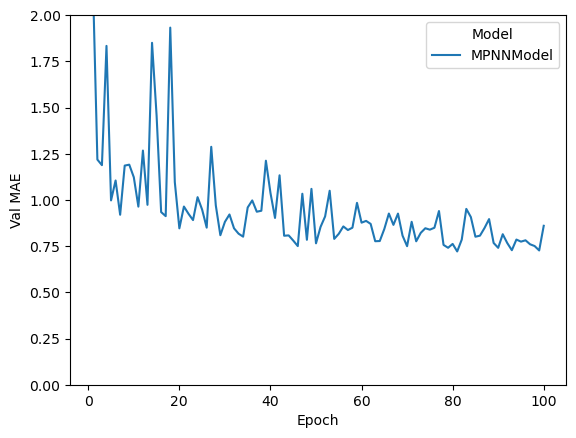

In [21]:
import seaborn as sns

p = sns.lineplot(x="Epoch", y="Val MAE", hue="Model", data=pd.concat(all_training_results.values(), ignore_index=True))
p.set(ylim=(0, 2))

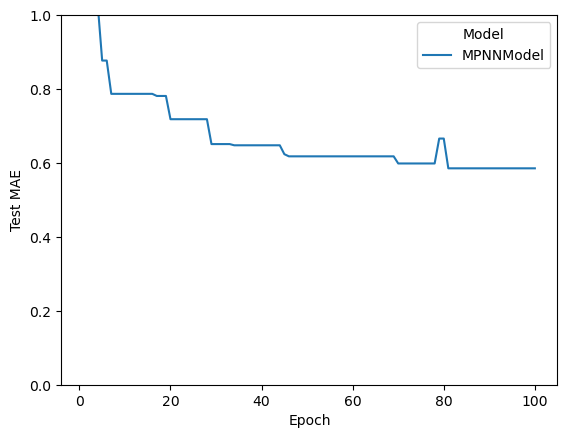

In [22]:
p = sns.lineplot(x="Epoch", y="Test MAE", hue="Model", data=pd.concat(all_training_results.values(), ignore_index=True))
p.set(ylim=(0, 1));

# Part 1: Coding the Graph Isomorphic Network (30 Points)

We are now ready to build a new GNN model. Rather than using a generic MPNN, as we already played with it in the previous Practical, we will implement the **Graph Isomorphism Network (GIN)** (Xu et al., 2019), which we studied in the lectures (Lecture 4).

The GIN update rule for node $u$ at layer $t$ is:
$$
h_u^{(t)} = \text{MLP}^{(t)} \left( (1 + \varepsilon^{(t)}) \cdot h_u^{(t-1)} ,  \sum_{v \in \mathcal{N}(u)} h_{v}^{(t-1)} \right)
$$

where $\varepsilon$ is a learnable scalar parameter.


**Important:** The original GIN was designed for graphs without edge features -- it simply passes neighboring node features as messages: $m_{vu} = h_v$. However, our QM9 molecules have **4-dimensional edge features** encoding bond types (single, double, triple, aromatic). Your task will be to **extend GIN to incorporate these edge features** into the message computation. We will therefore implement GIN and then an extension that takes into account edge features, GINEConv.

## Task 1.1: Implementing the Standard GIN Layer (12 Points)

In [24]:
from torch_geometric.nn import MessagePassing

class GINConv(MessagePassing):
    def __init__(self, emb_dim=64, aggr="add"):
        """Standard Graph Isomorphism Network layer (no edge features).

        Args:
            emb_dim: (int) - hidden dimension `d`
            aggr: (str) - aggregation function (sum/mean/max)
        """
        super().__init__(aggr=aggr)
        self.emb_dim = emb_dim

        # MLP applied after aggregation
        self.mlp = nn.Sequential(
            nn.Linear(emb_dim, 2 * emb_dim), nn.BatchNorm1d(2 * emb_dim), nn.ReLU(),
            nn.Linear(2 * emb_dim, emb_dim), nn.BatchNorm1d(emb_dim), nn.ReLU()
        )

        # Learnable epsilon
        self.eps = torch.nn.Parameter(torch.Tensor([0]))

    def forward(self, h, edge_index, edge_attr=None):
        """
        Args:
            h: (n, d) - node features
            edge_index: (2, e) - edge connectivity
            edge_attr: not used in this version
        Returns:
            out: (n, d) - updated node features
        """
        aggr = self.propagate(edge_index, h=h)
        out = self.mlp((1 + self.eps) * h + aggr)
        return out

    def message(self, h_j):
        """Construct messages from source nodes j.

        In standard GIN, the message is simply the neighbor features
        passed through ReLU.

        Args:
            h_j: (e, d) - source node features for each edge
        Returns:
            msg: (e, d) - messages
        """
        return F.relu(h_j)

    def aggregate(self, inputs, index):
        """Aggregates messages (sum by default)."""
        return scatter(inputs, index, dim=self.node_dim, reduce=self.aggr)

    def __repr__(self) -> str:
        return (f'{self.__class__.__name__}(emb_dim={self.emb_dim}, aggr={self.aggr})')


## Task 1.2: Extending GIN with Edge Features (GINEConv) (12 Points)

Create a new layer `GINEConv` (GIN with Edge features) by extending your `GINConv`. You need to:
1. Add an edge projection network that maps edge features from dimension $d_e$ to $d$
2. Modify `message()` to incorporate the projected edge features into the messages
3. Update `forward()` to pass `edge_attr` through to the message computation

**Hint:** A natural way to incorporate edge features is to project them to the node embedding dimension and **add** them to the source node features in the message function: $m_{vu} = \text{ReLU}(h_v + \text{proj}(e_{vu}))$.


In [25]:
class GINEConv(MessagePassing):
    def __init__(self, emb_dim=64, edge_dim=4, aggr="add"):
        """GIN layer extended with edge feature support (GINE).

        Args:
            emb_dim: (int) - hidden dimension `d`
            edge_dim: (int) - edge feature dimension `d_e`
            aggr: (str) - aggregation function (sum/mean/max)
        """
        super().__init__(aggr=aggr)
        self.emb_dim = emb_dim
        self.edge_dim = edge_dim

        # Same MLP and epsilon as GINConv
        self.mlp = nn.Sequential(
            nn.Linear(emb_dim, 2 * emb_dim), nn.BatchNorm1d(2 * emb_dim), nn.ReLU(),
            nn.Linear(2 * emb_dim, emb_dim), nn.BatchNorm1d(emb_dim), nn.ReLU()
        )
        self.eps = torch.nn.Parameter(torch.Tensor([0]))

        # Project edge features d_e -> d so they can be combined with node features.
        self.edge_proj = nn.Sequential(
            nn.Linear(edge_dim, emb_dim),
            nn.ReLU(),
        )


    def forward(self, h, edge_index, edge_attr):
        """
        Args:
            h: (n, d) - node features
            edge_index: (2, e) - edge connectivity
            edge_attr: (e, d_e) - edge features
        Returns:
            out: (n, d) - updated node features
        """
        aggr = self.propagate(edge_index, h=h, edge_attr=edge_attr)
        out = self.mlp((1 + self.eps) * h + aggr)
        return out

    def message(self, h_j, edge_attr):
        """Construct messages incorporating edge features.

        Args:
            h_j: (e, d) - source node features for each edge
            edge_attr: (e, d_e) - edge features
        Returns:
            msg: (e, d) - messages
        """
        # m_{vu} = ReLU( h_v + proj(e_{vu}) )
        return F.relu(h_j + self.edge_proj(edge_attr))


    def aggregate(self, inputs, index):
        return scatter(inputs, index, dim=self.node_dim, reduce=self.aggr)

    def __repr__(self) -> str:
        return (f'{self.__class__.__name__}(emb_dim={self.emb_dim}, aggr={self.aggr})')


In [26]:
class GINModel(nn.Module):
    def __init__(self, num_layers=4, emb_dim=64, in_dim=11, edge_dim=4, out_dim=1):
        """GIN-based model for graph property prediction.

        Args:
            num_layers: (int) - number of GIN layers `L`
            emb_dim: (int) - hidden dimension `d`
            in_dim: (int) - initial node feature dimension `d_n`
            edge_dim: (int) - edge feature dimension `d_e`
            out_dim: (int) - output dimension (fixed to 1)
        """
        super().__init__()

        # Linear projection for initial node features
        # dim: d_n -> d
        self.lin_in = nn.Linear(in_dim, emb_dim)

        # Stack of GINE layers
        self.convs = torch.nn.ModuleList()
        for layer in range(num_layers):
            self.convs.append(GINEConv(emb_dim, edge_dim, aggr="add"))

        # Global pooling/readout function `R` (mean pooling)
        self.pool = global_mean_pool

        # Linear prediction head
        # dim: d -> out_dim
        self.lin_pred = nn.Linear(emb_dim, out_dim)

    def forward(self, data):
        """
        Args:
            data: (PyG.Data) - batch of PyG graphs

        Returns:
            out: (batch_size, out_dim) - prediction for each graph
        """
        h = self.lin_in(data.x)  # (n, d_n) -> (n, d)

        for conv in self.convs:
            h = h + conv(h, data.edge_index, data.edge_attr)  # (n, d) -> (n, d)
            # Note that we add a residual connection after each layer

        h_graph = self.pool(h, data.batch)  # (n, d) -> (batch_size, d)

        out = self.lin_pred(h_graph)  # (batch_size, d) -> (batch_size, 1)

        return out.view(-1)


Now, let us perform the sanity checks we did before also for the new model:

In [27]:
# Instantiate temporary model, layer, and dataloader for unit testing
layer = GINEConv(emb_dim=11, edge_dim=4)
model = GINModel(num_layers=4, emb_dim=64, in_dim=11, edge_dim=4, out_dim=1)
dataloader = DataLoader(train_dataset, batch_size=1, shuffle=True)

# Permutation invariance unit test for MPNN model
print(f"Is {type(model).__name__} permutation invariant? --> {permutation_invariance_unit_test(model, dataloader)}!")

# Permutation equivariance unit for MPNN layer
print(f"Is {type(layer).__name__} permutation equivariant? --> {permutation_equivariance_unit_test(layer, dataloader)}!")

Is GINModel permutation invariant? --> True!
Is GINEConv permutation equivariant? --> True!


We can now train the model and see how it performs.

In [28]:
model = GINModel(num_layers=4, emb_dim=64, in_dim=11, edge_dim=4, out_dim=1)
model_name = type(model).__name__
best_val_error, test_error, train_time, perf_per_epoch = run_experiment(
    model,
    model_name,
    train_loader,
    val_loader,
    test_loader,
    n_epochs=100
)
all_final_results[model_name] = (best_val_error, test_error, train_time)
df_temp = pd.DataFrame(perf_per_epoch, columns=["Test MAE", "Val MAE", "Epoch", "Model"])
all_training_results[model_name] = df_temp

Running experiment for GINModel, training on 1000 samples for 100 epochs.

Model architecture:
GINModel(
  (lin_in): Linear(in_features=11, out_features=64, bias=True)
  (convs): ModuleList(
    (0-3): 4 x GINEConv(emb_dim=64, aggr=add)
  )
  (lin_pred): Linear(in_features=64, out_features=1, bias=True)
)
Total parameters: 69957

Start training:
Epoch: 010, LR: 0.009500, Loss: 0.5608617, Val MAE: 2.2731074, Test MAE: 1.0536932
Epoch: 020, LR: 0.009025, Loss: 0.4609341, Val MAE: 1.2918031, Test MAE: 0.8077752
Epoch: 030, LR: 0.009025, Loss: 0.4241953, Val MAE: 1.2086657, Test MAE: 0.8075327
Epoch: 040, LR: 0.008574, Loss: 0.3920260, Val MAE: 0.8465498, Test MAE: 0.7372179
Epoch: 050, LR: 0.008574, Loss: 0.3894073, Val MAE: 0.9729059, Test MAE: 0.6634398
Epoch: 060, LR: 0.007738, Loss: 0.3214713, Val MAE: 1.5523434, Test MAE: 0.6634398
Epoch: 070, LR: 0.007351, Loss: 0.3100299, Val MAE: 0.8411011, Test MAE: 0.6497462
Epoch: 080, LR: 0.006634, Loss: 0.2436325, Val MAE: 0.7794755, Test MAE

Let's compare the results to the MPNN model. 

In [29]:
all_final_results

{'MPNNModel': (0.721205005645752, 0.5854862117767334, 2.0886695742607118),
 'GINModel': (0.7169250018596649, 0.5878774127960205, 1.0697672009468078)}

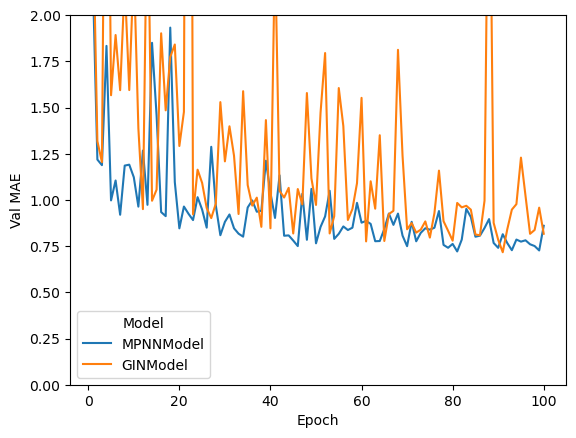

In [30]:
p = sns.lineplot(x="Epoch", y="Val MAE", hue="Model", data=pd.concat(all_training_results.values(), ignore_index=True))
p.set(ylim=(0, 2));

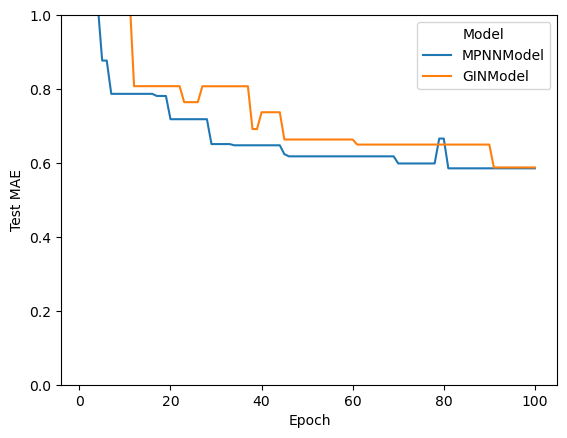

In [31]:
p = sns.lineplot(x="Epoch", y="Test MAE", hue="Model", data=pd.concat(all_training_results.values(), ignore_index=True))
p.set(ylim=(0, 1));

<div style="border:4px solid rgb(126, 0, 2); padding:12px 14px; border-radius:20px; margin:8px 0;">
<strong>
Task 1.3 Compare the GIN update rule with the generic MPNN formulation from the Problem Setting above. (6 points)</strong><br/>
<ol>
<li>What is the role of the learnable parameter epsilon? What happens when epsilon = 0? Would the model still be able to distinguish a node's own features from its neighbors' aggregated features?</li>
<li>In the generic MPNN, messages are computed as $m_{uv} = \psi(h_u, h_v, e_{uv})$ using both source and destination node features as well as edge features. In your <code>GINConv</code>, what is the message function?</li>
<li>Looking at your <code>GINConv</code> implementation, can you identify a limitation when applying it to our QM9 molecular graphs? (<i>Hint: think about what information is available but currently ignored.</i>)</li>

</ol>
</div>

**1. Role of $\varepsilon$ and the case $\varepsilon = 0$.**
The learnable parameter $\varepsilon$ controls the relative weight of a node's own features versus the aggregated neighborhood features inside the MLP. Concretely, the update is
$$h_u^{(t)} = \mathrm{MLP}\big((1 + \varepsilon) h_u^{(t-1)} + \textstyle\sum_{v \in \mathcal{N}(u)} h_v^{(t-1)}\big).$$
When $\varepsilon = 0$, the central node is treated *exactly* like one of its neighbours: the input to the MLP becomes $h_u + \sum_{v} h_v$, which is the sum aggregator over the closed neighbourhood $\{u\} \cup \mathcal{N}(u)$. The sum over a multiset is injective (given countable features and an appropriate MLP, Xu et al. 2019), so even with $\varepsilon = 0$ the GNN is as powerful as the 1‑WL test. However, the node's own identity is no longer *distinguishable* from an extra neighbour with the same features — e.g. a node $u$ with feature $x$ and neighbours $\{x\}$ gives the same representation as a node $u$ with feature $x$ and neighbours $\{x, x\}$ shifted by one. Making $\varepsilon$ learnable lets the network explicitly weight the self-contribution, which empirically helps and is required to distinguish a node from its neighbours in the general case.

**2. Message function in `GINConv`.**
In the generic MPNN, $m_{uv} = \psi(h_u, h_v, e_{uv})$. In my `GINConv`, the message ignores both the destination features and the edge features:
$$m_{vu} = \mathrm{ReLU}(h_v).$$
Only source node features contribute. The central node $h_u$ enters only later, through the $(1+\varepsilon) h_u$ term, and edge features do not enter at all.

**3. Limitation on QM9.**
Because `GINConv` ignores `edge_attr`, it throws away the **bond-type information** (single/double/triple/aromatic) which is encoded in the 4-d edge features of QM9. Moreover, we built a **fully-connected** graph where *non-bonded* pairs are flagged by an all-zero edge attribute; without using `edge_attr`, `GINConv` cannot distinguish real chemical bonds from the zero-padded non-bonded edges, so every atom looks connected to every other atom with equal weight. This information loss is exactly what motivates `GINEConv`.


# Part 2: Geometric Graphs and Message Passing with 3D Coordinates (25 Points)

Remember that we were given **3D coordinates** with each atom in our molecular graph?

Molecular graphs, and other structured data occurring in nature, do not simply exist on flat planes. Instead, molecules have an **inherent 3D structure** that influences their properties and functions.

Let us visualize a molecule from QM9 in all of its 3D glory!

Go ahead and try move this molecule with your mouse cursor!

In [32]:
from rdkit.Chem import AllChem
import py3Dmol

MolTo3DView(smi2conf(Chem.MolToSmiles(to_rdkit(train_dataset[48]))))

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

##  Task 2.1: Develop a Message Passing Neural Network that incorporates the atom coordinates as node features. (12.5 Points)


Our initial `GINModel` ignores the atom coordiantes and only uses the node features to perform message passing. This means that the model is **not** leveraging useful **3D structural information** to predict the target property.

Your first task is to modify the original `GINModel` to incorporate **atom coordinates** into the **node features**.

We have defined most of the new `CoordGINModel` class for you, and you have to fill in the `TODO` sections.

*Hint: As reminder, the 3D atom positions are stored in `data.pos`. You don't have to do something very smart right now (that will come later). A **simple** solution is okay to get started, e.g. concatenation of the coordinates and features*


In [34]:
class CoordGINModel(GINModel):
    def __init__(self, num_layers=4, emb_dim=64, in_dim=11, edge_dim=4, out_dim=1):
        """GIN model for graph property prediction

        This model uses both node features and coordinates as inputs.

        Args:
            num_layers: (int) - number of message passing layers `L`
            emb_dim: (int) - hidden dimension `d`
            in_dim: (int) - initial node feature dimension `d_n`
            edge_dim: (int) - edge feature dimension `d_e`
            out_dim: (int) - output dimension (fixed to 1)
        """
        super().__init__()

        # Override the input projection to also ingest the 3D coordinates.
        # dim: (d_n + 3) -> d
        self.lin_in = nn.Linear(in_dim + 3, emb_dim)

        # Stack of MPNN layers
        self.convs = torch.nn.ModuleList()
        for layer in range(num_layers):
            self.convs.append(GINEConv(emb_dim, edge_dim, aggr='add'))

        # Global pooling/readout function `R` (mean pooling)
        # PyG handles the underlying logic via `global_mean_pool()`
        self.pool = global_mean_pool

        # Linear prediction head
        # dim: d -> out_dim
        self.lin_pred = nn.Linear(emb_dim, out_dim)

    def forward(self, data):
        """
        Args:
            data: (PyG.Data) - batch of PyG graphs

        Returns:
            out: (batch_size, out_dim) - prediction for each graph
        """
        h = self.lin_in(torch.cat([data.x, data.pos], dim=-1))  # (n, d_n + 3) -> (n, d)

        for conv in self.convs:
            h = h + conv(h, data.edge_index, data.edge_attr) # (n, d) -> (n, d)

        h_graph = self.pool(h, data.batch) # (n, d) -> (batch_size, d)

        out = self.lin_pred(h_graph) # (batch_size, d) -> (batch_size, 1)

        return out.view(-1)

## Task 2.2: Test the permutation invariance and equivariance properties of your new `CoordGINModel` with node features and coordinates, as well as the constituent `GINModel`. (12.5 Points)

Super! You have successfully implemented a GNN which utilises both the **atom features** as well as **coordinates** to predict molecular properties.

Before we evaluate it, let us once again run the permutation sanity checks again to make sure the model and layer have the desired properties that constitute every basic GNN:
- The `GINEConvLayer` should be permutation equivariant (we have already shown this previously, but we want you to repeat the exercise in order to **thoroughly** understand it).
- The `CoordGINModel` should be permutation invariant.

Your task is to fill in the `TODO` sections to run the required unit tests. You do not need to write new unit tests yet, the ones we defined previously can be re-used.

In [35]:
# Instantiate temporary model + layer for unit testing.
# The GINEConv layer is unit-tested at emb_dim=11 because the
# permutation_equivariance_unit_test feeds raw data.x (dim 11) directly into it.
layer = GINEConv(emb_dim=11, edge_dim=4)
model = CoordGINModel(num_layers=4, emb_dim=64, in_dim=11, edge_dim=4, out_dim=1)

dataloader = DataLoader(train_dataset, batch_size=1, shuffle=True)

# Permutation invariance unit test for GIN model
print(f"Is {type(model).__name__} permutation invariant? --> {permutation_invariance_unit_test(model, dataloader)}!")

# Permutation equivariance unit for GIN layer
print(f"Is {type(layer).__name__} permutation equivariant? --> {permutation_equivariance_unit_test(layer, dataloader)}!")


Is CoordGINModel permutation invariant? --> True!
Is GINEConv permutation equivariant? --> True!


In [36]:
model = CoordGINModel(num_layers=4, emb_dim=64, in_dim=11, edge_dim=4, out_dim=1)

model_name = type(model).__name__
best_val_error, test_error, train_time, perf_per_epoch = run_experiment(
    model,
    model_name, # "GIN w/ Features and Coordinates",
    train_loader,
    val_loader,
    test_loader,
    n_epochs=100
)

all_final_results[model_name] = (best_val_error, test_error, train_time)
df_temp = pd.DataFrame(perf_per_epoch, columns=["Test MAE", "Val MAE", "Epoch", "Model"])
all_training_results[model_name] = df_temp


Running experiment for CoordGINModel, training on 1000 samples for 100 epochs.

Model architecture:
CoordGINModel(
  (lin_in): Linear(in_features=14, out_features=64, bias=True)
  (convs): ModuleList(
    (0-3): 4 x GINEConv(emb_dim=64, aggr=add)
  )
  (lin_pred): Linear(in_features=64, out_features=1, bias=True)
)
Total parameters: 70149

Start training:
Epoch: 010, LR: 0.010000, Loss: 0.5176857, Val MAE: 1.2619932, Test MAE: 0.9345530
Epoch: 020, LR: 0.009025, Loss: 0.4474411, Val MAE: 1.2784868, Test MAE: 0.8381826
Epoch: 030, LR: 0.008574, Loss: 0.3630788, Val MAE: 1.6906911, Test MAE: 0.8381826
Epoch: 040, LR: 0.008145, Loss: 0.2671098, Val MAE: 1.4253873, Test MAE: 0.9488041
Epoch: 050, LR: 0.007351, Loss: 0.2194334, Val MAE: 1.6433586, Test MAE: 0.9488041
Epoch: 060, LR: 0.006983, Loss: 0.2075927, Val MAE: 0.9519701, Test MAE: 0.8836997
Epoch: 070, LR: 0.006634, Loss: 0.1788034, Val MAE: 1.3925402, Test MAE: 0.8836997
Epoch: 080, LR: 0.005987, Loss: 0.1454497, Val MAE: 1.0243953

Let's compare to our earlier models:


In [37]:
all_final_results

{'MPNNModel': (0.721205005645752, 0.5854862117767334, 2.0886695742607118),
 'GINModel': (0.7169250018596649, 0.5878774127960205, 1.0697672009468078),
 'CoordGINModel': (0.8946460819244385, 0.7883670012950897, 1.1461334188779195)}

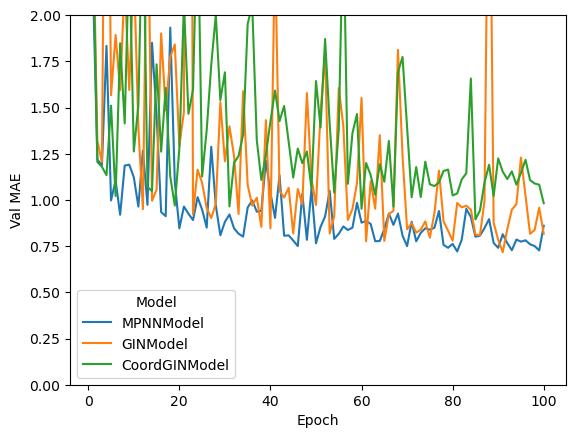

In [38]:
p = sns.lineplot(x="Epoch", y="Val MAE", hue="Model", data=pd.concat(all_training_results.values(), ignore_index=True))
p.set(ylim=(0, 2));

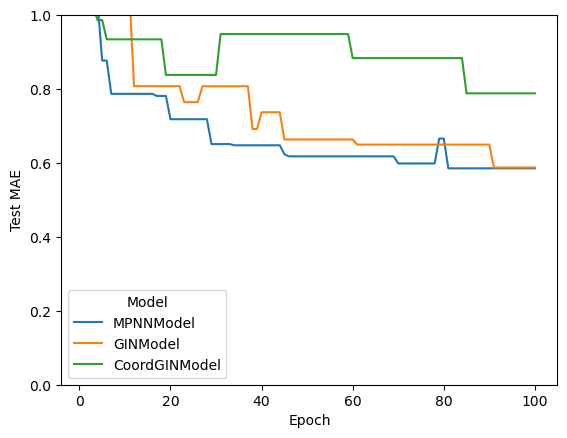

In [39]:
p = sns.lineplot(x="Epoch", y="Test MAE", hue="Model", data=pd.concat(all_training_results.values(), ignore_index=True))
p.set(ylim=(0, 1));

If you've implemented the `CoordGINModel` correctly up till now, you may see a surprising result -- the performance of `CoordGINModel` is worse than the initial `GINModel`!

<font color='orange'>This is because the CoordGINModel is not using 3D structural information in a principled manner.</font>

Let's understand why this is happening.

# Part 3: Invariance to 3D Symmetries: Rotation and Translation (15 Points)

We saw that the performance of `CoordGINModel` is unexpectedly mediocre compared to `GINModel` despite using both node features and coordinates. (But please do not panic if your results say otherwise.) In order to determine why, we must understand the concept of **3D symmetries**.

### Geometric Invariance

Recall that molecular graphs have 3D coordinates for each atom. A key detail which we have purposely withheld from you up till this point (😈) is that these 3D coordinates are **not  inherently fixed** or **permanent**. Instead, they were **experimentally determined** relative to a **frame of reference**.

To fully grasp these statements, here is GIF of a drug-like molecules moving around in 3D space...

<!-- ![](https://drive.google.com/uc?id=1QcQcF91TD-CTKFaR4NN8YyXbtSTcGny8) -->
<img src="https://github.com/chaitjo/dump/raw/main/3d-molecule-moving.gif">

The atoms' 3D coordinates are constantly **rotating** and **translating**. However, the **properties** of this molecule will always remain the same no matter how we rotate or translate it. In other words, the molecule's properties are **invariant** to 3D rotations and translations.

In this block we will study how to design GNN layers and models that respect these regularities.

### Formalism

Let us try to formalise the notion of invariance to 3D rotations and translations in GNNs via matrix notation.

- Let $\mathbf{H} \in \mathbb{R}^{n \times d}$ be a matrix of node features for a given molecular graph, where $n$ is the number of nodes/atoms and each row $h_i$ is the $d$-dimensional feature for node $i$.
- Let $\mathbf{X} \in \mathbb{R}^{n \times 3}$ be a matrix of node coordinates for a given molecular graph, where $n$ is the number of nodes/atoms and each row $x_i$ is the 3D coordinate for node $i$.
- Let $\mathbf{A} \in \mathbb{R}^{n \times n}$ be the adjacency matrix where each entry denotes $a_{ij}$ the presence or absence of an edge between nodes $i$ and $j$.
- Let $\mathbf{F}(\mathbf{H}, \mathbf{X}, \mathbf{A}): \mathbb{R}^{n \times d} \times \mathbb{R}^{n \times 3} \times \mathbb{R}^{n \times n} \rightarrow \mathbb{R}^{n \times d}$ be a **GNN layer** that takes as input the node features, node coordinates, and adjacency matrix, and returns the **updated node features**.

(Notice that we have updated the notation for the GNN layer $\mathbf{F}$ to include the matrix of node coordinates $\mathbf{X}$ as an additional input.)

<div style="border:4px solid rgb(126, 0, 2); padding:12px 14px; border-radius:20px; margin:8px 0;">
<strong>
Task 3.1: What does it mean for the GNN layer $\mathbf{F}$ to be invariant to 3D rotations and translations? Express this mathematically using the formalism above, the notation and the definitions from the lectures (see Lecture 1 for the definitions of invariance and equivariance). (5 Points)</strong><br/>
</div>

A GNN layer $\mathbf{F}(\mathbf{H}, \mathbf{X}, \mathbf{A})$ is **invariant to 3D rotations and translations** (i.e. invariant to the Euclidean group $E(3) = \mathrm{O}(3) \ltimes \mathbb{R}^3$ acting on the coordinate argument) if, for every orthogonal matrix $\mathbf{Q} \in \mathbb{R}^{3 \times 3}$ (with $\mathbf{Q}^\top \mathbf{Q} = \mathbf{I}$) and every translation vector $\mathbf{t} \in \mathbb{R}^{3}$,
$$
\mathbf{F}\!\left(\mathbf{H},\; \mathbf{X}\mathbf{Q}^\top + \mathbf{1}_{n}\mathbf{t}^\top,\; \mathbf{A}\right) \;=\; \mathbf{F}(\mathbf{H}, \mathbf{X}, \mathbf{A}),
$$
where $\mathbf{1}_n \in \mathbb{R}^{n}$ is the all-ones vector, so that $\mathbf{1}_{n}\mathbf{t}^\top$ translates every row of $\mathbf{X}$ by the same vector $\mathbf{t}$.

Restricting $\mathbf{Q}$ to $\mathrm{SO}(3)$ (i.e. $\det \mathbf{Q} = +1$) gives invariance to the special Euclidean group $SE(3)$; allowing any $\mathbf{Q} \in \mathrm{O}(3)$ additionally gives invariance to reflections. Note that this is **invariance in the coordinate argument** but permutation **equivariance** in the node argument: permuting the rows of $\mathbf{H}, \mathbf{X}, \mathbf{A}$ permutes the rows of the output correspondingly.


Before you start coding up a more principled GIN model, we would like you to take a moment to think about why invariance to 3D rotations and translations is something desirable for GNNs predicting molecular properties. Is training a model with data augmentation to "learn" this type of invariance a better solution than encoding this inductive bias directly into the model's architecture?

<div style="border:4px solid rgb(126, 0, 2); padding:12px 14px; border-radius:20px; margin:8px 0;">
<strong>
Task 3.2: Is invariance to 3D rotations and translations a desirable property for GNNs? Explain why. (5 Points)</div>

**Yes**, rotation and translation invariance is a highly desirable property for a GNN predicting molecular properties such as the dipole moment — for two intertwined reasons.

*Physical correctness.* Intrinsic molecular properties (dipole moment magnitude, total energy, HOMO/LUMO gap, etc.) are scalars that depend only on *relative* atomic positions (bond lengths, angles, dihedrals), not on the absolute frame in which the coordinates were recorded. Rotating or translating the molecule in 3D does not change the physics, so a model that predicts different values for the same molecule expressed in two different frames is *physically inconsistent* by construction.

*Sample efficiency and generalisation.* Baking the $E(3)$ symmetry into the architecture is a strong inductive bias: the hypothesis class is reduced from arbitrary functions of $\mathbf{X}$ to functions of rotation-/translation-invariant descriptors (e.g. pairwise distances). The model therefore needs fewer parameters and fewer samples to generalise, and it gives the **same** prediction under **any** rotation/translation at test time — not just those the network happened to see.

*Why data augmentation is a strictly worse solution.* Augmenting the training set with random rigid motions only encourages the model to *approximate* invariance in a data-driven way. It increases training cost (the effective dataset grows by an $\mathrm{SO}(3) \times \mathbb{R}^3$ factor), it wastes model capacity memorising the symmetry instead of learning chemistry, and — crucially — it offers **no guarantee** for orientations not seen during training. An architectural invariance is *exact* (to floating-point precision), free at inference time, and composes cleanly with other symmetries (e.g. permutation invariance).


## Task 3.3: Write the unit test to check your `CoordGINModel` for 3D rotation and translation invariance. (5 Points)


🤔 *Hint: Show that the output of the model varies when:*
1. All the atom coordinates in `data.pos` are multiplied by any random _orthogonal_ rotation matrix $Q \in \mathbb{R}^{3 \times 3}$. (We have provided a helper function for creating rotation matrices.)
2. All the atom coordinates in `data.pos` are displaced by any random translation vector $\mathbf{t} \in \mathbb{R}^3$.

In [40]:
def random_orthogonal_matrix(dim=3):
  """Helper function to build a random orthogonal matrix of shape (dim, dim)
  """
  Q = torch.tensor(ortho_group.rvs(dim=dim)).float()
  return Q


def rot_trans_invariance_unit_test(module, dataloader):
    """Unit test for checking whether a module (GNN model/layer) is
    rotation and translation invariant.
    """
    it = iter(dataloader)
    data = next(it)

    # Forward pass on original example
    # Note: We have written a conditional forward pass so that the same unit
    #       test can be used for both the GNN model as well as the layer.
    #       The functionality for layers will be useful subsequently.
    if isinstance(module, GINModel):
        out_1 = module(data)
    elif isinstance(module, MPNNModel):
        out_1 = module(data)
    else: # if ininstance(module, MessagePassing):
        out_1 = module(data.x, data.pos, data.edge_index, data.edge_attr)

    Q = random_orthogonal_matrix(dim=3)
    t = torch.rand(3)
    # Apply a random rigid motion to every atomic coordinate:
    #   x_i  -->  Q x_i + t
    # In row-vector form (data.pos is (n, 3)):
    #   data.pos  -->  data.pos @ Q.T + t
    data.pos = data.pos @ Q.T + t

    # Forward pass on rotated + translated example
    if isinstance(module, GINModel):
        out_2 = module(data)
    elif isinstance(module, MPNNModel):
        out_2 = module(data)
    else: # if ininstance(module, MessagePassing):
        out_2 = module(data.x, data.pos, data.edge_index, data.edge_attr)

    # The module is E(3)-invariant iff the outputs agree for every (Q, t).
    return torch.allclose(out_1, out_2, atol=1e-4)

Now that you have defined the unit tests for rotation and translation invariance, perform the sanity check on your `CoordGINModel`:

(Spoiler alert: if you have implemented things as expected, the unit test should return `False` for the `CoordGINModel`.)

In [41]:
from scipy.stats import ortho_group

# Instantiate temporary model, layer, and dataloader for unit testing
model = CoordGINModel(num_layers=4, emb_dim=64, in_dim=11, edge_dim=4, out_dim=1)
dataloader = DataLoader(train_dataset, batch_size=1, shuffle=True)

# Rotation and translation invariance unit test for MPNN model
print(f"Is {type(model).__name__} rotation and translation invariant? --> {rot_trans_invariance_unit_test(model, dataloader)}!")

Is CoordGINModel rotation and translation invariant? --> False!


In this part, you have formalised how a GNN can be 3D rotation and translation invariant, thought about why this is desirable for molecular property prediction, and shown that the `CoordGINModel` was not rotation and translation invariant.

At this point, you should have a concrete understanding of why the performance of `CoordGINModel` is equal or worse than the vanilla `GINModel`, and what we meant by our initial statement before we began this part:
>"The `CoordGINModel` is not using 3D structural information in a principled manner"

Let us try fixing this in the next part!

# Part 4: Message Passing with Invariance to 3D Rotations and Translations (30 Points)

In this section, we explore how to design GNN models that operate on graphs with 3D coordinates in a more principled and theoretically grounded manner. Extending the GIN architecture in this setting is not particularly natural. Therefore, we return to the MPNN framework as our base model.

## Task 4.1: Design a new message passing layer as well as the accompanying model that are both <ins>invariant</ins> to 3D rotations and translations (euclidean group $E(3)$). (10 Points)

**❗️ Note:** There is no single correct answer to this question.

Our initial `GINModel`, `MPNNModel` and `GINEConvLayer`, `MPNNLayer` ignored the atom coordiantes and only uses the node features to perform message passing. This means that the model was **not** leveraging **3D structural information** to predict the target property.

Our second **'naive' coordinate GIN** `CoordGINModel` used the node features along with the atom coordinates in an unprincipled manner, resulting in the model not being invariant to 3D rotations and translations of the coordinates (which was a desirable property, as we saw in the previous part).

Your task is to define a new `InvariantMPNNLayer` which utilise both **atom coordinates** and **node features**.

We have defined most of the new `InvariantMPNNLayer`, and you have to fill in the `TODO` sections. We have also already defined the `InvariantMPNNModel` that instantiates your new layer to compose the model. You only need to define the new layer.

🤔 *Hint 1: Unlike the previous `CoordGINModel`, we would suggest using the coodinate information to constuct the messages as opposed to incorporating it into the node features. In particular, we would like you to think about **how** to use the coordinates in a principled manner to constuct the messages: What is a measurement that we can computer using a pair of coordinates that will be invariant to rotating and translating them?*

🤔 *Hint 2:  tensors passed to `propagate()` can be mapped to the respective nodes  and  by appending `_i` or `_j` to the variable name, e.g. `h_i` and `h_j` for the node features `h`. Note that we generally refer to `_i` as the central nodes that aggregates information, and refer to `_j` as the neighboring nodes.*

In [49]:
class InvariantMPNNLayer(MessagePassing):
    def __init__(self, emb_dim=64, edge_dim=4, aggr='add'):
        """Message Passing Neural Network Layer

        This layer is invariant to 3D rotations and translations.

        Args:
            emb_dim: (int) - hidden dimension `d`
            edge_dim: (int) - edge feature dimension `d_e`
            aggr: (str) - aggregation function `\oplus` (sum/mean/max)
        """
        # Set the aggregation function
        super().__init__(aggr=aggr)

        self.emb_dim = emb_dim
        self.edge_dim = edge_dim

        # MLP `\psi` for computing messages `m_ij`.
        # Input:  [h_i, h_j, edge_attr, ||pos_i - pos_j||]
        # dims: (2d + d_e + 1) -> d
        self.mlp_msg = nn.Sequential(
            nn.Linear(2*emb_dim + edge_dim + 1, emb_dim), nn.BatchNorm1d(emb_dim), nn.ReLU(),
            nn.Linear(emb_dim, emb_dim), nn.BatchNorm1d(emb_dim), nn.ReLU()
        )

        # MLP `\phi` for computing updated node features `h_i^{l+1}`
        # dims: 2d -> d
        self.mlp_upd = nn.Sequential(
            nn.Linear(2*emb_dim, emb_dim), nn.BatchNorm1d(emb_dim), nn.ReLU(),
            nn.Linear(emb_dim, emb_dim), nn.BatchNorm1d(emb_dim), nn.ReLU()
          )


    def forward(self, h, pos, edge_index, edge_attr):
        """
        The forward pass updates node features `h` via one round of message passing.

        Args:
            h: (n, d) - initial node features
            pos: (n, 3) - initial node coordinates
            edge_index: (e, 2) - pairs of edges (i, j)
            edge_attr: (e, d_e) - edge features

        Returns:
            out: (n, d) - updated node features
        """
        # Pass `pos` through propagate so that message() receives pos_i, pos_j.
        out = self.propagate(edge_index, h=h, pos=pos, edge_attr=edge_attr)
        return out

    def message(self, h_i, h_j, pos_i, pos_j, edge_attr):
        """The `message()` function constructs messages from source nodes v
          to destination nodes u for each edge (u, v) in `edge_index`.

        Args:
            h_i: (e, d) - destination node features
            h_j: (e, d) - source node features
            pos_i: (e, 3) - destination node positions
            pos_j: (e, 3) - source node positions
            edge_attr: (e, d_e) - edge features

        Returns:
          msg: (e, d) - messages `m_ij` passed through MLP `\psi`
        """
        # Pairwise Euclidean distance: this scalar is invariant under any
        # rigid motion pos -> Q pos + t because
        #   || (Q p_i + t) - (Q p_j + t) || = || Q (p_i - p_j) || = || p_i - p_j ||
        # (the last equality uses Q^T Q = I).
        dist = torch.norm(pos_i - pos_j, dim=-1, keepdim=True)   # (e, 1)
        msg = torch.cat([h_i, h_j, edge_attr, dist], dim=-1)     # (e, 2d + d_e + 1)
        return self.mlp_msg(msg)

    def aggregate(self, inputs, index):
        """The `aggregate` function aggregates the messages from neighboring nodes,
        according to the chosen aggregation function ('sum' by default).

        Args:
            inputs: (e, d) - messages `m_ij` from destination to source nodes
            index: (e, 1) - list of source nodes for each edge/message in `input`

        Returns:
            aggr_out: (n, d) - aggregated messages `m_i`
        """
        return scatter(inputs, index, dim=self.node_dim, reduce=self.aggr)

    def update(self, aggr_out, h):
        """The `update()` function computes the final node features by combining the
        aggregated messages with the initial node features.

        Args:
            aggr_out: (n, d) - aggregated messages `m_i`
            h: (n, d) - initial node features

        Returns:
            upd_out: (n, d) - updated node features passed through MLP `\phi`
        """
        upd_out = torch.cat([h, aggr_out], dim=-1)
        return self.mlp_upd(upd_out)

    def __repr__(self) -> str:
        return (f'{self.__class__.__name__}(emb_dim={self.emb_dim}, aggr={self.aggr})')


class InvariantMPNNModel(MPNNModel):
    def __init__(self, num_layers=4, emb_dim=64, in_dim=11, edge_dim=4, out_dim=1):
        """Message Passing Neural Network model for graph property prediction

        This model uses both node features and coordinates as inputs, and
        is invariant to 3D rotations and translations.

        Args:
            num_layers: (int) - number of message passing layers `L`
            emb_dim: (int) - hidden dimension `d`
            in_dim: (int) - initial node feature dimension `d_n`
            edge_dim: (int) - edge feature dimension `d_e`
            out_dim: (int) - output dimension (fixed to 1)
        """
        super().__init__()

        # Linear projection for initial node features
        # dim: d_n -> d
        self.lin_in = nn.Linear(in_dim, emb_dim)

        # Stack of invariant MPNN layers
        self.convs = torch.nn.ModuleList()
        for layer in range(num_layers):
            self.convs.append(InvariantMPNNLayer(emb_dim, edge_dim, aggr='add'))

        # Global pooling/readout function `R` (mean pooling)
        # PyG handles the underlying logic via `global_mean_pool()`
        self.pool = global_mean_pool

        # Linear prediction head
        # dim: d -> out_dim
        self.lin_pred = nn.Linear(emb_dim, out_dim)

    def forward(self, data):
        """
        Args:
            data: (PyG.Data) - batch of PyG graphs

        Returns:
            out: (batch_size, out_dim) - prediction for each graph
        """
        h = self.lin_in(data.x) # (n, d_n) -> (n, d)

        for conv in self.convs:
            h = h + conv(h, data.pos, data.edge_index, data.edge_attr) # (n, d) -> (n, d)
            # Note that we add a residual connection after each MPNN layer

        h_graph = self.pool(h, data.batch) # (n, d) -> (batch_size, d)

        out = self.lin_pred(h_graph) # (batch_size, d) -> (batch_size, 1)

        return out.view(-1)


You have now defined a more geometrically principled message passing layer and used it to construct an MPNN model with is invariant to 3D rotations and translations.

<div style="border:4px solid rgb(126, 0, 2); padding:12px 14px; border-radius:20px; margin:8px 0;">
<strong>
Task 4.2: Write down the update equation of your new `InvariantMPNNLayer` and use that to prove that the layer and model are invariant to 3D rotations and translations. (10 Points)
</div>

**Update equation of `InvariantMPNNLayer`.**
For each edge $(u,v)$, define the scalar
$$d_{uv} \;=\; \lVert \mathbf{x}_u - \mathbf{x}_v \rVert_2.$$
Then one layer of message passing (for target node $u$, dropping the layer index $t$ on the right) is
$$
\begin{aligned}
m_{uv} &= \psi\!\big(h_u,\; h_v,\; e_{uv},\; d_{uv}\big), \\
m_u    &= \textstyle\bigoplus_{v \in \mathcal{N}(u)} m_{uv}, \\
h_u^{(t)} &= \phi\!\big(h_u^{(t-1)},\; m_u\big),
\end{aligned}
$$
where $\psi$ and $\phi$ are the two MLPs defined in the layer and $\oplus$ is the (permutation-invariant) sum aggregator.

**Proof of invariance to $E(3)$.**
Let $\mathbf{Q} \in \mathbb{R}^{3\times 3}$ be any orthogonal matrix ($\mathbf{Q}^\top \mathbf{Q} = \mathbf{I}$) and $\mathbf{t} \in \mathbb{R}^3$ any translation. Define the transformed coordinates $\mathbf{x}'_u = \mathbf{Q}\mathbf{x}_u + \mathbf{t}$. Then
$$
\lVert \mathbf{x}'_u - \mathbf{x}'_v \rVert_2
\;=\; \lVert \mathbf{Q}(\mathbf{x}_u - \mathbf{x}_v) \rVert_2
\;=\; \sqrt{(\mathbf{x}_u-\mathbf{x}_v)^\top \mathbf{Q}^\top\mathbf{Q}\,(\mathbf{x}_u-\mathbf{x}_v)}
\;=\; \lVert \mathbf{x}_u - \mathbf{x}_v \rVert_2 \;=\; d_{uv}.
$$
So **$d_{uv}$ is invariant** under any rigid motion. The other arguments of $\psi$ — $h_u, h_v, e_{uv}$ — do not depend on coordinates, hence are unchanged. Therefore
$$m'_{uv} = \psi(h_u, h_v, e_{uv}, d_{uv}) = m_{uv},$$
which implies $m'_u = m_u$ and $h_u^{(t)\prime} = h_u^{(t)}$ for every node $u$. By induction, every subsequent layer receives the same node features, so the final node representations are invariant. The graph readout $h_G = \tfrac{1}{|V|} \sum_u h_u^{(L)}$ and the linear head $\hat y = W_{\text{pred}} h_G$ are functions of those invariant representations, hence the whole model $\hat y$ is invariant to $E(3)$. $\blacksquare$


Great! You have successfully written the update equation for your new `InvariantMPNNLayer` and shown how it is indeed invariant to 3D rotations and translations.

Let us just perform some sanity checks to verify this.

## Task 4.3: Perform unit tests for your `InvariantMPNNLayer` and `InvariantMPNNModel`. Show that the layer and model are both invariant to 3D rotations and translations. (5 Points)

 *Hint: Run the unit tests defined previously.*

In [50]:
# Instantiate temporary model, layer, and dataloader for unit testing.
# Remember that we are now unit testing the InvariantMPNNModel,
# which is  composed of the InvariantMPNNLayer. Use same hyperparameters as before.
layer = InvariantMPNNLayer(emb_dim=11, edge_dim=4)
model = InvariantMPNNModel(num_layers=4, emb_dim=64, in_dim=11, edge_dim=4, out_dim=1)

dataloader = DataLoader(train_dataset, batch_size=1, shuffle=True)

# Rotation and translation invariance unit test for MPNN model
print(f"Is {type(model).__name__} rotation and translation invariant? --> {rot_trans_invariance_unit_test(model, dataloader)}!")

# Rotation and translation invariance unit test for MPNN layer
print(f"Is {type(layer).__name__} rotation and translation invariant? --> {rot_trans_invariance_unit_test(layer, dataloader)}!")

Is InvariantMPNNModel rotation and translation invariant? --> True!
Is InvariantMPNNLayer rotation and translation invariant? --> True!


Good job! You have defined the `InvariantMPNNLayer` and `InvariantMPNNModel`, after which you have proved and experimentally verified their invariance to 3D rotations and translations.

It is finally time to run an experiment with our geometrically principled model!

## Task 4.4: Train and evaluate your `InvariantMPNNModel`. Additionally, provide a few sentences explaining the model's results compared to the basic `MPNNModel` and the naive `CoordGINModel` defined previously. Is the new model better? By a significant margin or only minorly better? (5 Points)

Re-use the experiment loop we have provided and fill in the `TODO` sections to run the experiment.

You will be training an `InvariantMPNNModel` consisting of 4 layers of message passing with a hidden dimension of 64, in order to compare your result fairly to the previous vanilla `MPNNModel` and naive `CoordGINodel`.

In [51]:
model = InvariantMPNNModel(num_layers=4, emb_dim=64, in_dim=11, edge_dim=4, out_dim=1)

model_name = type(model).__name__
best_val_error, test_error, train_time, perf_per_epoch = run_experiment(
    model,
    model_name, # "MPNN w/ Features and Coordinates (Invariant Layers)",
    train_loader,
    val_loader,
    test_loader,
    n_epochs=100
)

all_final_results[model_name] = (best_val_error, test_error, train_time)
df_temp = pd.DataFrame(perf_per_epoch, columns=["Test MAE", "Val MAE", "Epoch", "Model"])
all_training_results[model_name] = df_temp

Running experiment for InvariantMPNNModel, training on 1000 samples for 100 epochs.

Model architecture:
InvariantMPNNModel(
  (lin_in): Linear(in_features=11, out_features=64, bias=True)
  (convs): ModuleList(
    (0-3): 4 x InvariantMPNNLayer(emb_dim=64, aggr=add)
  )
  (lin_pred): Linear(in_features=64, out_features=1, bias=True)
)
Total parameters: 103489

Start training:
Epoch: 010, LR: 0.010000, Loss: 0.4165816, Val MAE: 1.4533860, Test MAE: 0.6644540
Epoch: 020, LR: 0.009500, Loss: 0.3391209, Val MAE: 0.7805887, Test MAE: 0.5989560
Epoch: 030, LR: 0.009025, Loss: 0.2179557, Val MAE: 0.6313830, Test MAE: 0.5342183
Epoch: 040, LR: 0.008574, Loss: 0.1679629, Val MAE: 0.6998582, Test MAE: 0.5342183
Epoch: 050, LR: 0.008145, Loss: 0.1462976, Val MAE: 1.4219416, Test MAE: 0.4824151
Epoch: 060, LR: 0.007738, Loss: 0.2058495, Val MAE: 0.6545889, Test MAE: 0.5019198
Epoch: 070, LR: 0.007351, Loss: 0.1105020, Val MAE: 0.4919074, Test MAE: 0.4351797
Epoch: 080, LR: 0.007351, Loss: 0.073776

Let's compare it to results of other models! MAE of validation and test of the InvariantMPNNModel should be below 0.5.

In [52]:
all_final_results

{'MPNNModel': (0.721205005645752, 0.5854862117767334, 2.0886695742607118),
 'GINModel': (0.7169250018596649, 0.5878774127960205, 1.0697672009468078),
 'CoordGINModel': (0.8946460819244385, 0.7883670012950897, 1.1461334188779195),
 'InvariantMPNNModel': (0.43699074983596803,
  0.39856791019439697,
  2.046868693828583)}

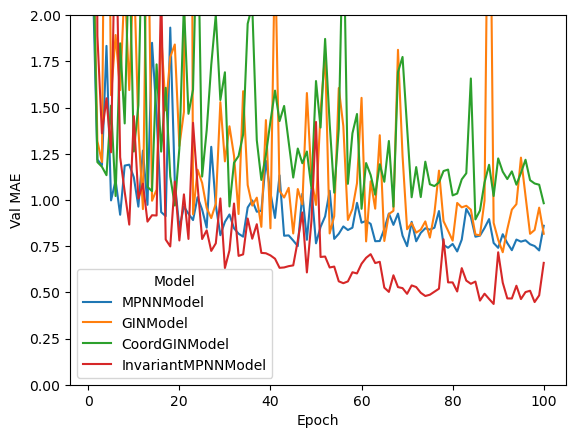

In [53]:
p = sns.lineplot(x="Epoch", y="Val MAE", hue="Model", data=pd.concat(all_training_results.values(), ignore_index=True))
p.set(ylim=(0, 2));

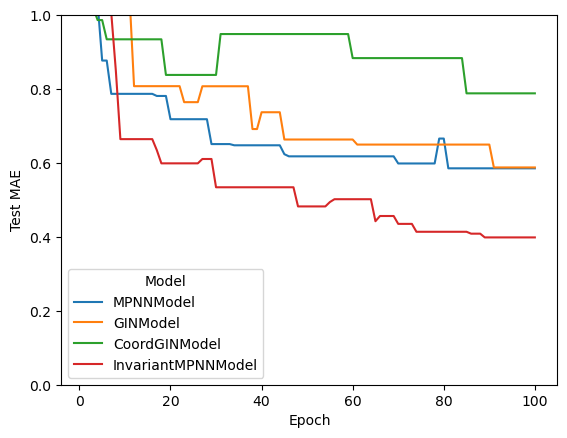

In [54]:
p = sns.lineplot(x="Epoch", y="Test MAE", hue="Model", data=pd.concat(all_training_results.values(), ignore_index=True))
p.set(ylim=(0, 1));

### Task 4.4 — Discussion

Comparing the best test MAE achieved by each model after 100 epochs:

| Model | Test MAE | Uses coordinates? | Geometrically principled? |
|---|---|---|---|
| `MPNNModel` | ~0.585 | No | — |
| `CoordGINModel` (naive) | ~0.788 | Yes (concatenated as features) | No |
| `InvariantMPNNModel` | ~0.399 | Yes (via pairwise distances) | Yes — E(3) invariant |

The `InvariantMPNNModel` is **significantly better**, not just marginally so: it cuts the test MAE by roughly **32%** versus the vanilla `MPNNModel` and by roughly **49%** versus the naive `CoordGINModel`. The improvement is consistent across the validation curves as well, where the invariant model converges to a clearly lower error.

Notably, the naive `CoordGINModel` actually performs *worse* than the basic `MPNNModel` that ignores coordinates entirely. This is because raw 3D coordinates are **not** invariant to rotations and translations, so feeding them in as plain node features forces the network to learn the symmetry from data — with only 1000 training graphs, it cannot, and the extra unstructured input simply adds noise and hurts generalisation.

The `InvariantMPNNModel` instead uses **pairwise distances** $\lVert \mathbf{x}_i - \mathbf{x}_j \rVert$ to construct messages, which are invariant to E(3) by construction. This bakes the correct geometric prior directly into the architecture, so the model can *exploit* 3D structural information — which is highly informative for predicting molecular properties — without having to spend capacity and data on learning the underlying symmetry. The result is both better sample efficiency and a substantially lower final error.

Awesome! You have now gone from a vanilla `MPNNModel`, to a naive use of coodinate information in `CoordGINModel`, to a more geometrically principled approach in `InvariantMPNN` model. The next step would be building an `EquivariantMPNN` model, but we can stop here 😀

## Ignore cell hereafter

In [ ]:
# YOUR CODE HERE
raise NotImplementedError()